In [342]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as img
import cv2
import os

In [343]:
os.listdir('/kaggle/input/datasets/ashfakyeafi/glasses-classification-dataset')

['validate', 'test', 'train']

In [344]:
data_train = {
    'glasses':0,
    'noglasses':1
}

In [345]:
img.imread('/kaggle/input/datasets/ashfakyeafi/glasses-classification-dataset/train/glasses/row-1-column-1.jpg').shape

(155, 159, 3)

In [346]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [347]:
X_train = []
y_train = []
for i in os.listdir('/kaggle/input/datasets/ashfakyeafi/glasses-classification-dataset/train'):
    try:
        for j in os.listdir(f'/kaggle/input/datasets/ashfakyeafi/glasses-classification-dataset/train/{i}'):
            image = cv2.imread(f'/kaggle/input/datasets/ashfakyeafi/glasses-classification-dataset/train/{i}/{j}')
            image = cv2.resize(image, (224,224))
            if len(image.shape) == 2:
                image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
            else:   
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = image[:,:,:3]
            X_train.append(image)
            y_train.append(data_train[i])  
    except:
        print(i)
X_train = np.array(X_train)    
y_train = np.array(y_train)    

In [348]:
X_train.shape

(104, 224, 224, 3)

In [349]:
y_train.shape

(104,)

In [350]:
X_val = []
y_val = []
for i in os.listdir('/kaggle/input/datasets/ashfakyeafi/glasses-classification-dataset/validate'):
    try:
        for j in os.listdir(f'/kaggle/input/datasets/ashfakyeafi/glasses-classification-dataset/validate/{i}'):
            image = cv2.imread(f'/kaggle/input/datasets/ashfakyeafi/glasses-classification-dataset/validate/{i}/{j}')
            image = cv2.resize(image, (224,224))
            if len(image.shape) == 2:
                image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
            else:   
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = image[:,:,:3]
            X_val.append(image)
            y_val.append(data_train[i])      
    except:
        print(i)
X_val = np.array(X_val)    
y_val = np.array(y_val)    

In [351]:
X_val.shape

(40, 224, 224, 3)

In [352]:
y_val.shape

(40,)

In [353]:
data_test = {
    '1': 0,
    '7':1
}

In [354]:
X_test = []
y_test = []
for i in os.listdir('/kaggle/input/datasets/ashfakyeafi/glasses-classification-dataset/test'):
    try:
        image = cv2.imread(f'/kaggle/input/datasets/ashfakyeafi/glasses-classification-dataset/test/{i}')
        image = cv2.resize(image, (224,224))
        if len(image.shape) == 2:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        else:   
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = image[:,:,:3]
        X_test.append(image)
        y_test.append(data_test[i.split('-')[1]])            
    except:
        print(i)
X_test = np.array(X_test)    
y_test = np.array(y_test)    

In [355]:
X_test.shape

(20, 224, 224, 3)

In [356]:
y_test.shape

(20,)

In [357]:
from sklearn.utils import shuffle

In [358]:
X_train,y_train = shuffle(X_train,y_train, random_state=42)
X_test,y_test = shuffle(X_test,y_test, random_state=42)
X_val,y_val = shuffle(X_val,y_val, random_state=42)

In [359]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, GlobalAveragePooling2D
from keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from keras.optimizers import Adam

In [367]:
base_model = MobileNetV2(weights='imagenet', include_top=False,)

/tmp/ipykernel_55/2870589175.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False,)


In [374]:
base_model.trainable=False
# for i in base_model.layers[:-20]:
#     layers.trainable = False

In [375]:
data_augmentation = Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
  layers.RandomContrast(0.1),
])

In [376]:
model = Sequential([
    layers.Input(shape=(224,224,3)),
    data_augmentation,
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

In [377]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [378]:
model.summary()

Model: "sequential_46"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_45 (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_13 (Lambda)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_15     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [379]:
model.fit(X_train,y_train, validation_data=(X_val,y_val), epochs=30, batch_size=32)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 974ms/step - accuracy: 0.7337 - loss: 0.5959 - val_accuracy: 0.5000 - val_loss: 0.6892
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 603ms/step - accuracy: 0.6938 - loss: 0.5080 - val_accuracy: 1.0000 - val_loss: 0.3155
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 596ms/step - accuracy: 0.8284 - loss: 0.4174 - val_accuracy: 0.7750 - val_loss: 0.4123
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 620ms/step - accuracy: 0.9032 - loss: 0.3382 - val_accuracy: 0.7750 - val_loss: 0.3985
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 610ms/step - accuracy: 0.9091 - loss: 0.2772 - val_accuracy: 1.0000 - val_loss: 0.1919
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 585ms/step - accuracy: 0.8719 - loss: 0.3007 - val_accuracy: 0.9750 - val_loss: 0.2594
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 622ms/step - accuracy: 0.9422 - loss: 0.2214 - val_accuracy: 0.6750 - val_loss: 0.4142
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 606ms/step - accuracy: 0.9752 - loss: 0.2054 - val_accuracy: 0.9250 - val_loss:

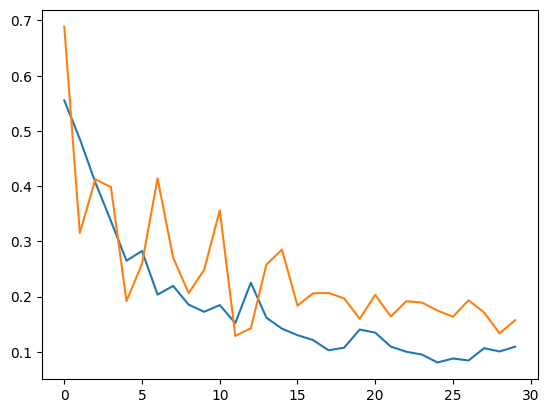

In [380]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

In [381]:
model.evaluate(X_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.9500 - loss: 0.1505


[0.1504913568496704, 0.949999988079071]